# Scanner usage example

In [1]:
from pathlib import Path
from ultralytics import YOLO
from app.scanner_api.app_models import Scanner, OrderModel # necessary imports.
import matplotlib.pyplot as plt
import cv2

## Model loading

The `Scanner` model is a pipeline composed by two models: `YOLO` and `OrderModel`, so to use it, we have to load our `YOLO` and `OrderModel` models, then we give those models to our `Scanner` object when creating an instance.

The `YOLO` model is loaded by giving the path to a yolo model file to the `YOLO` constructor, the `OrderModel` is loaded by giving it the path to .csv file that contains the data of a base shelf in the yolo format (columns being class, x, y, w, h).

And that's it, we are ready to use it!

In [2]:
model_path = Path.cwd().parent/'models'/'my_model.pt'
shelf_path = Path.cwd().parent/'src'/'app'/'scanner_api'/'shelves'/'BATERIAS (1F) 0,36M.csv'
test_img = Path.cwd().parent/'data'/'test'/'test_img.jpg'

yolo_model = YOLO(model_path)
order_model = OrderModel(shelf_path)

scanner = Scanner(yolo_model=yolo_model, order_model=order_model)
pred = scanner.predict(test_img)


image 1/1 c:\Users\shade\OneDrive\Documentos\My coding projects\4geeks projects\shelf-scanner\data\test\test_img.jpg: 640x320 2 Bateria Duracell AA 2Unds, 1 Bateria Duracell AAA 2Und, 1 Bateria Energizer A23 2Und, 1 Bateria Energizer Max 9V, 2 Bateria Energizer Max AA 4 Unds, 2 Bateria Energizer Max AAA 2 Unds, 3 Bateria Energizer Max AAA 4 Unds, 1 Bateria Energizer Max C 2 Und, 1 Bateria Energizer Max D Alkalina 2 Und, 1 Bateria Kodak 9V EHD, 2 Bateria Philips Boton Litio 2032 X5s, 3 Bateria Philips Power Alkaline AA 2Unds, 3 Bateria Philips Power Alkaline AAA 2Unds, 2 Linterna Rayovac Recargable Mini 5 Leds, 292.7ms
Speed: 7.5ms preprocess, 292.7ms inference, 16.4ms postprocess per image at shape (1, 3, 640, 320)


## The ScannerResult class

The `predict` method of the scanner object returns a `ScannerResult` object. This object is a dataclass that stores the results of the `YOLO` and `OrderModel` models. These results can be accessed using the `yolo_result` and `order_result` properties. 

### order_result

The order result property stores a tuple containing two DataFrames.

In [3]:
print(f'order_result type: {type(pred.order_result)}')
print(f'order_result length: {len(pred.order_result)}')

order_result type: <class 'tuple'>
order_result length: 2


The first DataFrame in the tuple contains the expected SKUs in the image that is being scanned. If the `expected_SKU` was found in the image in the position its given position (`pos` column), the `detected` value will be `True` for that product, if the product in the position was different from the `expected_SKU` it will be `False`.

In [4]:
pred.order_result[0]

,pos,cls,expected_SKU,detected
0,0,4,Bateria Energizer Max AA 2Und,False
1,1,11,Bateria Philips Boton Litio 2032 X5,True
2,2,11,Bateria Philips Boton Litio 2032 X5,True
3,3,14,Linterna Rayovac Recargable Mini 5 Led,True
4,4,10,Bateria Kodak 9V EHD,True
5,5,6,Bateria Energizer Max AAA 2 Und,True
6,6,8,Bateria Energizer Max C 2 Und,True
7,7,5,Bateria Energizer Max AA 4 Und,True
8,8,7,Bateria Energizer Max AAA 4 Und,True
9,9,9,Bateria Energizer Max D Alkalina 2 Und,True


The second DataFrame has a similar structure information related to the scanned image, in this DataFrame the `pos` column is calculated by the `OrderModel` model using the x, y values and the `detected_SKU` column stores SKU of the equivalent class detected by the `YOLO` model. 

In [5]:
pred.order_result[1]

,x,y,w,h,cls,pos,detected_SKU
0,515.326660,920.793701,374.496033,325.537018,6.0,0,Bateria Energizer Max AAA 2 Und
1,750.055237,970.152710,572.886047,308.994873,11.0,1,Bateria Philips Boton Litio 2032 X5
2,1002.527771,980.635620,571.101746,255.014771,11.0,2,Bateria Philips Boton Litio 2032 X5
3,1288.149658,1056.921997,763.520203,350.074829,14.0,3,Linterna Rayovac Recargable Mini 5 Led
4,927.499390,1542.788330,367.885254,294.202087,10.0,4,Bateria Kodak 9V EHD
5,551.247803,1474.695557,352.908813,322.426575,6.0,5,Bateria Energizer Max AAA 2 Und
6,1284.710938,1971.519287,284.167603,259.483765,8.0,6,Bateria Energizer Max C 2 Und
7,920.772705,1964.072754,292.219604,290.230225,5.0,7,Bateria Energizer Max AA 4 Und
8,593.534973,1970.721924,304.540039,291.999542,7.0,8,Bateria Energizer Max AAA 4 Und
9,1291.052490,2332.344482,300.924805,270.568237,14.0,9,Linterna Rayovac Recargable Mini 5 Led


In [6]:
pred.yolo_result

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Bateria Duracell AA 2Und', 1: 'Bateria Duracell AAA 2Und', 2: 'Bateria Energizer A23 2Und', 3: 'Bateria Energizer Max 9V', 4: 'Bateria Energizer Max AA 2Und', 5: 'Bateria Energizer Max AA 4 Und', 6: 'Bateria Energizer Max AAA 2 Und', 7: 'Bateria Energizer Max AAA 4 Und', 8: 'Bateria Energizer Max C 2 Und', 9: 'Bateria Energizer Max D Alkalina 2 Und', 10: 'Bateria Kodak 9V EHD', 11: 'Bateria Philips Boton Litio 2032 X5', 12: 'Bateria Philips Power Alkaline AA 2Und', 13: 'Bateria Philips Power Alkaline AAA 2Und', 14: 'Linterna Rayovac Recargable Mini 5 Led'}
obb: None
orig_img: array([[[151, 161, 168],
        [163, 173, 180],
        [174, 184, 191],
        ...,
        [ 77, 144, 139],
        [ 84, 151, 146],
        [ 86, 153, 148]],

       [[154, 164, 171],
        [155, 165, 172],
        [169, 179, 186],
        ...,
        [ 74, 141

## example: printing the detection image

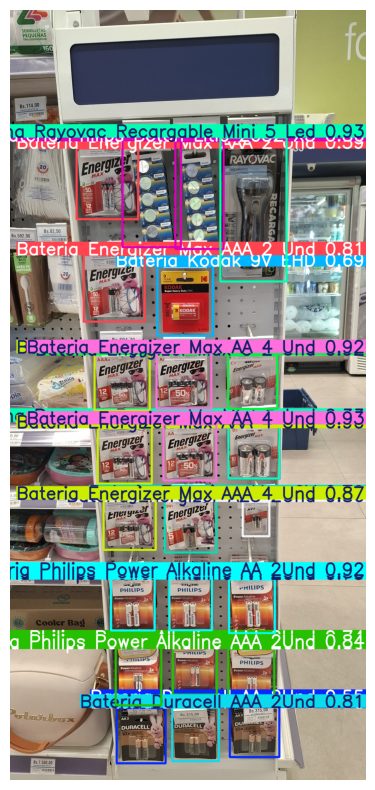

In [7]:
img_arr = pred.yolo_result.plot()
img = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis('off')
plt.show()